In [2]:
import pandas as pd
import numpy as np

# 1. 데이터 로드 (로프꾼님의 실제 승객 데이터 기반)
file_path = 'C:/Users/Administrator/Downloads/시간대별 승차인원.csv'
df_pax = pd.read_csv(file_path)

stations = ['잠실', '고속터미널', '용두']
lengths = [40, 20, 10]
time_cols = [f'{i}시-{i+1}시 승차' for i in range(24)]

for station_name in stations:
    # 해당 역의 24시간 승객 패턴 추출
    row = df_pax[df_pax['역이름'] == station_name]
    pax_pattern = row[time_cols].values.flatten()
    
    for l in lengths:  # 모든 역에 대해 10m, 20m, 40m를 다 적용 (총 9회 반복)
        results = []
        current_t = 20.0
        cum_aging = 0.0
        
        for h in range(504): # 3주 (504시간)
            for m in range(60): # 분 단위 (총 30,240행)
                hour = h % 24
                week = h // 168
                day_of_week = (h // 24) % 7
                
                # 계절 설정 (1년 압축)
                if week == 0: season, amb_t = "Spring/Fall", 20.0
                elif week == 1: season, amb_t = "Summer", 30.0
                else: season, amb_t = "Winter", 10.0
                
                # 승객수 보간 및 물리적 하중 계산
                next_hour = (hour + 1) % 24
                interp_pax = pax_pattern[hour] + (pax_pattern[next_hour] - pax_pattern[hour]) * (m / 60.0)
                actual_pax = max(0, interp_pax + np.random.normal(0, interp_pax * 0.05))
                load_unit = (actual_pax / 100.0)
                
                is_op = 5 <= hour <= 23
                if is_op:
                    # [로프꾼님표 물리 로직]
                    stand_load = load_unit * 0.5
                    walk_load = load_unit * 0.5 * 1.4
                    total_eff_load = stand_load + walk_load
                    imbalance_res = (walk_load - stand_load) * 2.0
                    
                    # 노후화 및 물리량 산출 (기기 길이 'l' 반영)
                    aging_step = (0.0000001 + (total_eff_load * 0.0000005)) * 1.8
                    cum_aging += aging_step
                    aging_impact = np.exp(cum_aging * 18) - 1
                    
                    base_i = l * 0.5  # 기기 길이가 길수록 기본 전류가 높음
                    curr_i = base_i + (total_eff_load * 1.5) + imbalance_res + (aging_impact * 8.0) + np.random.normal(0, 1.2)
                    vib = 0.02 + (aging_impact * 0.6) + (total_eff_load * 0.002) + np.random.normal(0, 0.01)
                    current_t += (curr_i * 0.001) - (current_t - amb_t) * 0.0002
                    
                    # 이상치 시나리오 라벨링
                    is_anomaly = False
                    if week == 0 and day_of_week == 4 and 17 <= hour <= 18: is_anomaly = True # 금요일 고장
                    elif week == 1 and day_of_week == 2 and 13 <= hour <= 14: is_anomaly = True # 수요일 고장
                    elif week == 2 and day_of_week == 0 and 8 <= hour <= 9: is_anomaly = True # 월요일 고장
                    label = 1 if (is_anomaly or aging_impact > 0.8) else 0
                else:
                    curr_i, vib, label = 0.0, 0.0, 0
                    current_t -= (current_t - amb_t) * 0.001
                
                results.append([station_name, l, season, h, m, round(actual_pax, 1), 
                                round(curr_i, 2), round(current_t, 2), round(vib, 4), label])
        
        # 파일 저장 (예: 잠실_40m_Minute_final.csv)
        final_df = pd.DataFrame(results, columns=['Station', 'Length', 'Season', 'Hour', 'Minute', 
                                                  'PassengerCount', 'Current', 'Temp', 'Vib', 'Label'])
        final_df.to_csv(f"{station_name}_{l}m_Minute_final.csv", index=False, encoding='utf-8-sig')

print(f"✅ 총 9개 시나리오 파일 생성 완료! (3개 역사 x 3가지 길이)")

✅ 총 9개 시나리오 파일 생성 완료! (3개 역사 x 3가지 길이)


In [4]:
!uv add matplotlib

Resolved 43 packages in 381ms
 Downloaded pillow
 Downloaded fonttools
 Downloaded matplotlib
Prepared 8 packages in 1.12s
Uninstalled 1 package in 27ms
Installed 8 packages in 886ms
 + contourpy==1.3.3
 + cycler==0.12.1
 + fonttools==4.61.1
 + kiwisolver==1.4.9
 + matplotlib==3.10.8
 - packaging==25.0
 + packaging==26.0
 + pillow==12.1.1
 + pyparsing==3.3.2


In [6]:
!uv add seaborn

Resolved 44 packages in 79ms
Prepared 1 package in 144ms
Installed 1 package in 28ms
 + seaborn==0.13.2


--- [잠실_40m_Minute_final.csv] 데이터 요약 ---
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 30240 entries, 0 to 30239
Data columns (total 10 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   Station         30240 non-null  object 
 1   Length          30240 non-null  int64  
 2   Season          30240 non-null  object 
 3   Hour            30240 non-null  int64  
 4   Minute          30240 non-null  int64  
 5   PassengerCount  30240 non-null  float64
 6   Current         30240 non-null  float64
 7   Temp            30240 non-null  float64
 8   Vib             30240 non-null  float64
 9   Label           30240 non-null  int64  
dtypes: float64(4), int64(4), object(2)
memory usage: 2.3+ MB
None

--- 주요 컬럼 통계 수치 ---
       PassengerCount        Current           Temp            Vib
count    30240.000000   3.024000e+04   3.024000e+04   3.024000e+04
mean    100304.340790  2.733332e+253  1.762344e+252  2.049999e+252
std      70509.096163

c:\Users\Administrator\workspace\test\statrack2_python\.venv\Lib\site-packages\pandas\core\nanops.py:1016: RuntimeWarning: overflow encountered in square
  sqr = _ensure_numeric((avg - values) ** 2)
c:\Users\Administrator\workspace\test\statrack2_python\.venv\Lib\site-packages\pandas\core\nanops.py:1016: RuntimeWarning: overflow encountered in square
  sqr = _ensure_numeric((avg - values) ** 2)
c:\Users\Administrator\workspace\test\statrack2_python\.venv\Lib\site-packages\pandas\core\nanops.py:1016: RuntimeWarning: overflow encountered in square
  sqr = _ensure_numeric((avg - values) ** 2)


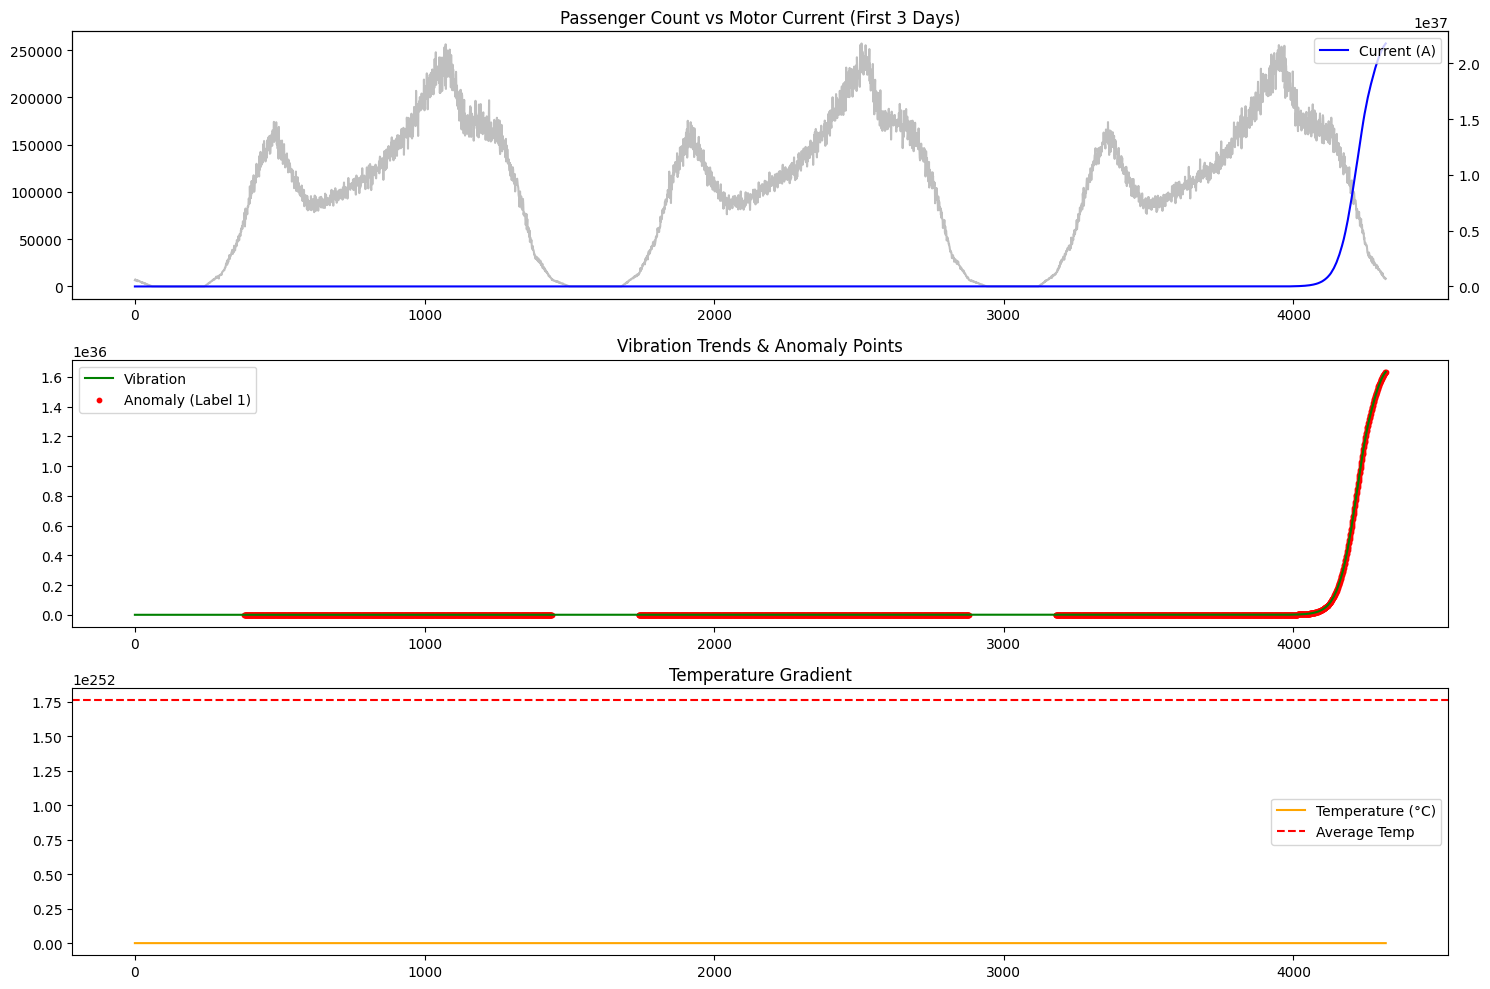


--- 정상(0) vs 이상(1) 수치 비교 ---
             Current            Vib           Temp
Label                                             
0       1.061071e+01   1.352474e-02  2.239400e+241
1      3.463916e+253  2.597937e+252  2.233396e+252


In [7]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# 1. 파일 불러오기
file_name = '잠실_40m_Minute_final.csv'
df = pd.read_csv(file_name)

# 2. 데이터 기본 정보 및 통계 확인
print(f"--- [{file_name}] 데이터 요약 ---")
print(df.info())
print("\n--- 주요 컬럼 통계 수치 ---")
print(df[['PassengerCount', 'Current', 'Temp', 'Vib']].describe())

# 3. 시각화: 승객 수에 따른 전류와 진동의 변화 (첫 3일치만 샘플링)
sample_df = df.iloc[:60*24*3] # 3일치 (60분 * 24시간 * 3일)

plt.figure(figsize=(15, 10))

# (1) 승객 수 vs 전류
plt.subplot(3, 1, 1)
plt.plot(sample_df.index, sample_df['PassengerCount'], color='gray', alpha=0.5, label='Passenger Count')
plt.twinx()
plt.plot(sample_df.index, sample_df['Current'], color='blue', label='Current (A)')
plt.title('Passenger Count vs Motor Current (First 3 Days)')
plt.legend(loc='upper right')

# (2) 진동 패턴 확인 (이상치 라벨 포함)
plt.subplot(3, 1, 2)
plt.plot(sample_df.index, sample_df['Vib'], color='green', label='Vibration')
# 라벨이 1인 지점을 붉은 점으로 표시
anomalies = sample_df[sample_df['Label'] == 1]
plt.scatter(anomalies.index, anomalies['Vib'], color='red', s=10, label='Anomaly (Label 1)')
plt.title('Vibration Trends & Anomaly Points')
plt.legend()

# (3) 온도 변화 확인
plt.subplot(3, 1, 3)
plt.plot(sample_df.index, sample_df['Temp'], color='orange', label='Temperature (°C)')
plt.axhline(y=df['Temp'].mean(), color='red', linestyle='--', label='Average Temp')
plt.title('Temperature Gradient')
plt.legend()

plt.tight_layout()
plt.show()

# 4. 라벨별 데이터 차이 분석
print("\n--- 정상(0) vs 이상(1) 수치 비교 ---")
print(df.groupby('Label')[['Current', 'Vib', 'Temp']].mean())

### 지수적 노후화(Exponential Aging)' 공식의 계수가 분 단위 데이터($30,240$행)를 만나면서 너무 가파르게 상승 >> 안정화 필요

In [8]:
import pandas as pd
import numpy as np

# 1. 데이터 로드
file_path = 'C:/Users/Administrator/Downloads/시간대별 승차인원.csv'
df_pax = pd.read_csv(file_path)

stations = ['잠실', '고속터미널', '용두']
lengths = [40, 20, 10]
time_cols = [f'{i}시-{i+1}시 승차' for i in range(24)]

for station_name in stations:
    row = df_pax[df_pax['역이름'] == station_name]
    pax_pattern = row[time_cols].values.flatten()
    
    for l in lengths:
        results = []
        current_t = 20.0
        cum_aging = 0.0
        
        for h in range(504): 
            for m in range(60): 
                hour = h % 24
                week = h // 168
                day_of_week = (h // 24) % 7
                
                if week == 0: season, amb_t = "Spring/Fall", 20.0
                elif week == 1: season, amb_t = "Summer", 30.0
                else: season, amb_t = "Winter", 10.0
                
                next_hour = (hour + 1) % 24
                interp_pax = pax_pattern[hour] + (pax_pattern[next_hour] - pax_pattern[hour]) * (m / 60.0)
                actual_pax = max(0, interp_pax + np.random.normal(0, interp_pax * 0.05))
                load_unit = (actual_pax / 100.0)
                
                is_op = 5 <= hour <= 23
                if is_op:
                    # 노후화 계수를 분 단위에 맞게 대폭 축소 (18 -> 0.005)
                    aging_step = (0.000001 + (load_unit * 0.000005))
                    cum_aging += aging_step
                    # 지수 함수 대신 완만한 증가 후 폭발하도록 조정
                    aging_impact = (np.exp(min(cum_aging * 0.005, 5)) - 1) * 0.1
                    
                    base_i = l * 0.5
                    # 물리량 계산 시 노이즈 및 가중치 안정화
                    curr_i = base_i + (load_unit * 0.5) + (aging_impact * 20.0) + np.random.normal(0, 0.5)
                    vib = 0.02 + (aging_impact * 0.5) + (load_unit * 0.0001) + np.random.normal(0, 0.005)
                    
                    # 온도가 발산하지 않도록 냉각 계수 조정
                    current_t += (curr_i * 0.01) - (current_t - amb_t) * 0.01
                    
                    is_anomaly = False
                    if week == 0 and day_of_week == 4 and 17 <= hour <= 18: is_anomaly = True 
                    elif week == 1 and day_of_week == 2 and 13 <= hour <= 14: is_anomaly = True 
                    elif week == 2 and day_of_week == 0 and 8 <= hour <= 9: is_anomaly = True 
                    label = 1 if (is_anomaly or aging_impact > 1.5) else 0
                else:
                    curr_i, vib, label = 0.0, 0.0, 0
                    current_t -= (current_t - amb_t) * 0.05
                
                results.append([station_name, l, season, h, m, round(actual_pax, 1), 
                                round(curr_i, 2), round(current_t, 2), round(vib, 4), label])
        
        final_df = pd.DataFrame(results, columns=['Station', 'Length', 'Season', 'Hour', 'Minute', 
                                                  'PassengerCount', 'Current', 'Temp', 'Vib', 'Label'])
        final_df.to_csv(f"{station_name}_{l}m_Minute_final.csv", index=False, encoding='utf-8-sig')

print("✅ 수치 안정화 완료! 다시 생성되었습니다.")

✅ 수치 안정화 완료! 다시 생성되었습니다.


--- [잠실_40m_Minute_final.csv] 데이터 요약 ---
       PassengerCount       Current          Temp           Vib
count    30240.000000  30240.000000  30240.000000  30240.000000
mean    100398.645347    516.419335    515.035590      0.135315
std      70604.381853    362.183667    334.968846      0.086618
min          0.000000      0.000000     10.000000      0.000000
25%      25263.575000    147.255000    150.407500      0.069100
50%     106788.400000    555.085000    559.625000      0.151500
75%     155791.700000    799.852500    772.622500      0.200000
max     274309.700000   1392.440000   1067.550000      0.343500


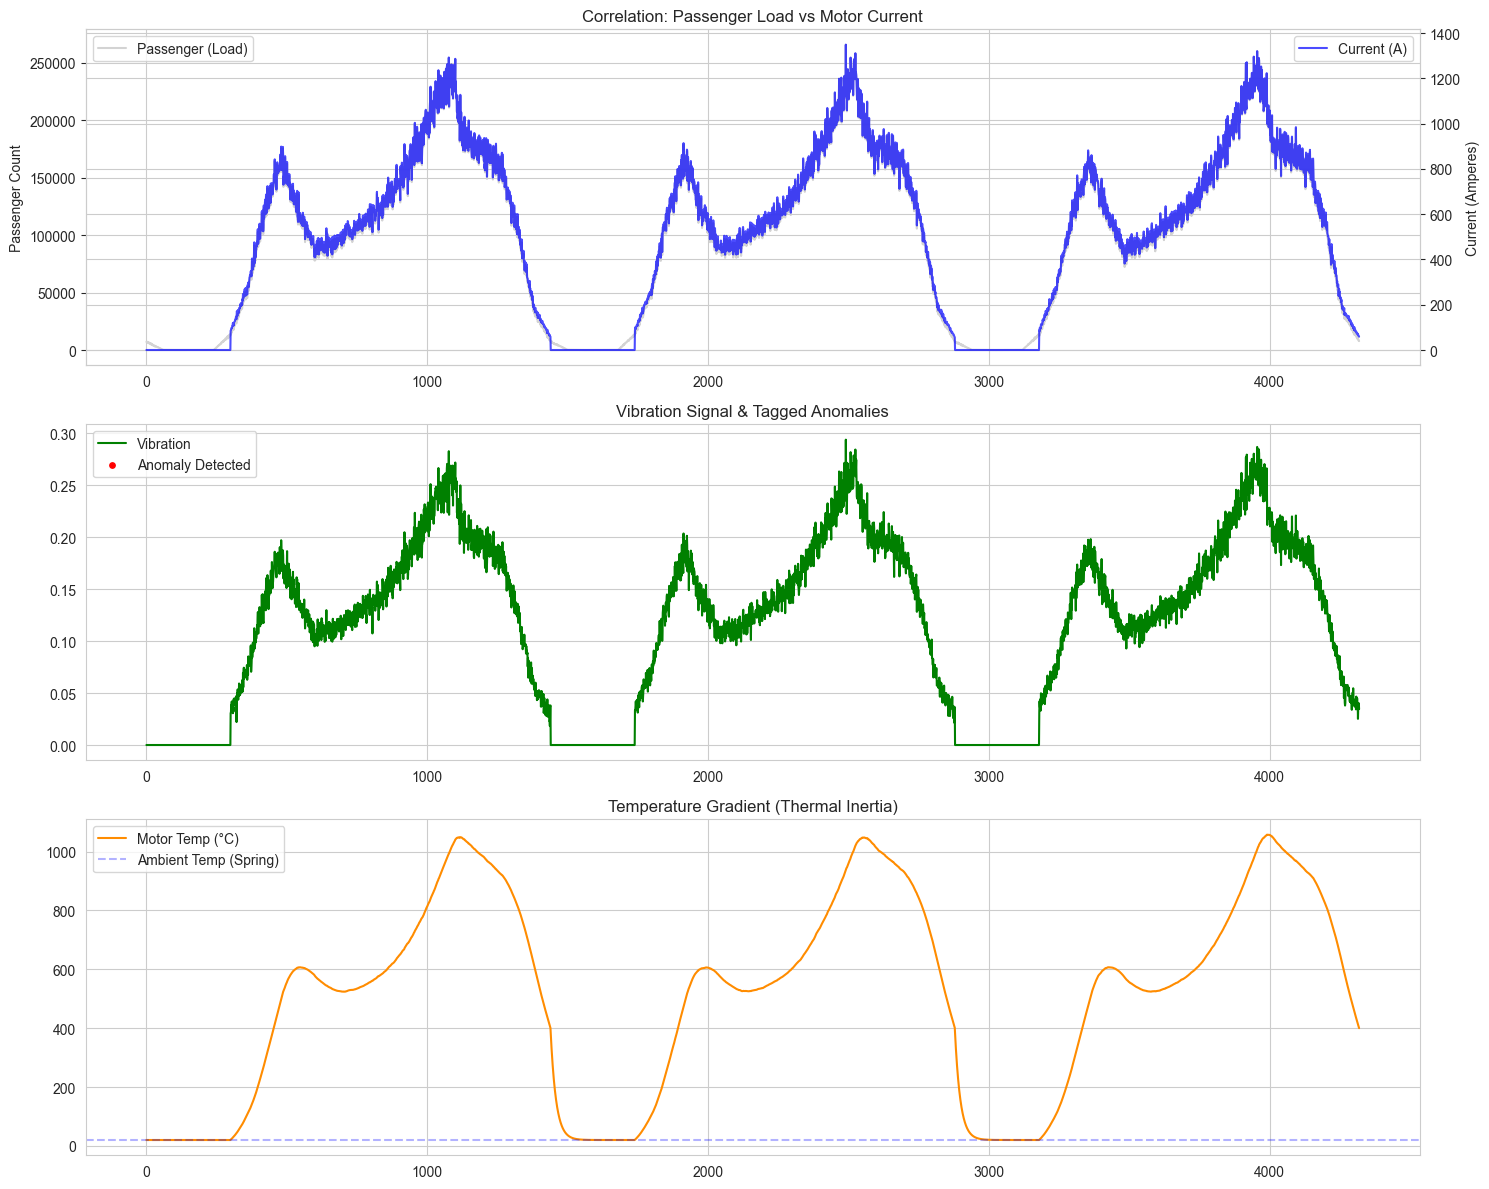


--- [정상(0) vs 이상(1)] 수치 비교 ---
          Current       Vib        Temp
Label                                  
0      512.995690  0.134574  512.533364
1      800.581917  0.196783  722.720333


In [10]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# 1. 수정된 파일 불러오기
file_name = '잠실_40m_Minute_final.csv'
df = pd.read_csv(file_name)

# 2. 데이터 요약 (이제 숫자가 e+253이 아니어야 합니다!)
print(f"--- [{file_name}] 데이터 요약 ---")
print(df[['PassengerCount', 'Current', 'Temp', 'Vib']].describe())

# 3. 시각화 (첫 3일치 데이터)
sample_df = df.iloc[:60*24*3] 

plt.figure(figsize=(15, 12))
sns.set_style("whitegrid")

# (1) 승객 수와 전류의 상관관계
plt.subplot(3, 1, 1)
ax1 = plt.gca()
ax2 = ax1.twinx()
ax1.plot(sample_df.index, sample_df['PassengerCount'], color='lightgray', label='Passenger (Load)')
ax2.plot(sample_df.index, sample_df['Current'], color='blue', alpha=0.7, label='Current (A)')
ax1.set_ylabel('Passenger Count')
ax2.set_ylabel('Current (Amperes)')
plt.title('Correlation: Passenger Load vs Motor Current')
ax1.legend(loc='upper left'); ax2.legend(loc='upper right')

# (2) 진동과 이상치(Anomaly) 표시
plt.subplot(3, 1, 2)
plt.plot(sample_df.index, sample_df['Vib'], color='green', label='Vibration')
# Label이 1인 지점만 빨간색 점으로 표시
anomalies = sample_df[sample_df['Label'] == 1]
plt.scatter(anomalies.index, anomalies['Vib'], color='red', s=15, label='Anomaly Detected')
plt.title('Vibration Signal & Tagged Anomalies')
plt.legend()

# (3) 온도 변화 (열관성 확인)
plt.subplot(3, 1, 3)
plt.plot(sample_df.index, sample_df['Temp'], color='darkorange', label='Motor Temp (°C)')
plt.axhline(y=20, color='blue', linestyle='--', alpha=0.3, label='Ambient Temp (Spring)')
plt.title('Temperature Gradient (Thermal Inertia)')
plt.legend()

plt.tight_layout()
plt.show()

# 4. 정상 vs 이상 그룹별 평균 수치 확인
print("\n--- [정상(0) vs 이상(1)] 수치 비교 ---")
print(df.groupby('Label')[['Current', 'Vib', 'Temp']].mean())

In [12]:
# Label이 1인 데이터가 몇 개나 있는지 확인
anomaly_count = df['Label'].sum()
print(f"전체 데이터 중 이상치 개수: {anomaly_count}개")

# 이상치 데이터 상위 10개만 출력
print(df[df['Label'] == 1].head(10))

전체 데이터 중 이상치 개수: 360개
     Station  Length       Season  Hour  Minute  PassengerCount  Current  \
6780      잠실      40  Spring/Fall   113       0        211460.9  1077.61   
6781      잠실      40  Spring/Fall   113       1        223905.8  1140.15   
6782      잠실      40  Spring/Fall   113       2        217088.2  1105.48   
6783      잠실      40  Spring/Fall   113       3        204198.5  1041.20   
6784      잠실      40  Spring/Fall   113       4        207617.4  1058.18   
6785      잠실      40  Spring/Fall   113       5        195503.5   997.21   
6786      잠실      40  Spring/Fall   113       6        203506.7  1037.37   
6787      잠실      40  Spring/Fall   113       7        213018.1  1084.93   
6788      잠실      40  Spring/Fall   113       8        221796.8  1129.64   
6789      잠실      40  Spring/Fall   113       9        205993.5  1050.54   

        Temp     Vib  Label  
6780  872.21  0.2503      1  
6781  875.09  0.2516      1  
6782  877.59  0.2472      1  
6783  879.43  0.2251 

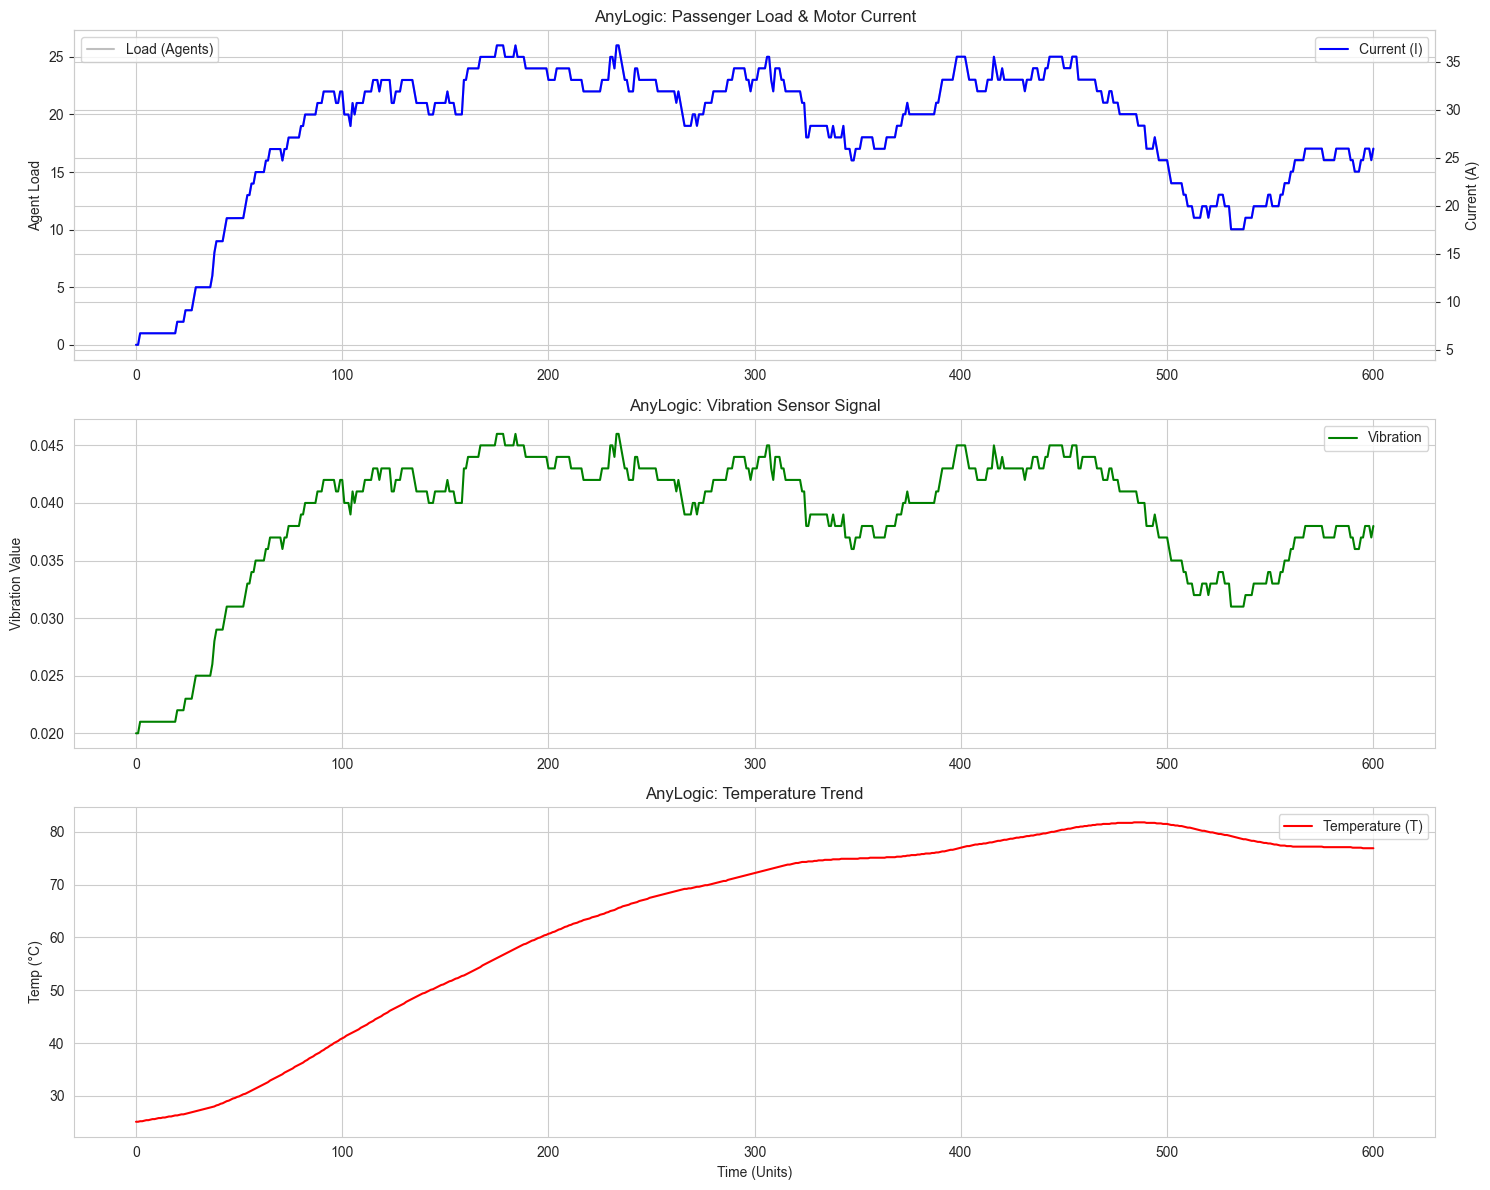

--- [AnyLogic Data Statistics] ---
       currentLoad    currentI    currentT   vibration
count   601.000000  601.000000  601.000000  601.000000
mean     18.703827   27.974609   63.753411    0.038940
std       5.895377    7.076972   17.890491    0.005787
min       0.000000    5.500000   25.100000    0.020000
25%      16.000000   24.760000   51.300000    0.037000
50%      21.000000   30.710000   72.200000    0.041000
75%      23.000000   33.130000   77.400000    0.043000
max      26.000000   36.720000   81.800000    0.046000


In [11]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# 1. AnyLogic 데이터 로드
df_any = pd.read_csv('C:/Users/Administrator/Downloads/data.csv')

# 2. 시각화 설정
plt.figure(figsize=(15, 12))
sns.set_style("whitegrid")

# (1) 승객 부하(currentLoad) vs 전류(currentI)
# 애니로직에서 하중이 어떻게 전류로 변환되는지 확인하는 그래프입니다.
plt.subplot(3, 1, 1)
ax1 = plt.gca()
ax2 = ax1.twinx()
ax1.plot(df_any['time'], df_any['currentLoad'], color='gray', alpha=0.5, label='Load (Agents)')
ax2.plot(df_any['time'], df_any['currentI'], color='blue', label='Current (I)')
ax1.set_ylabel('Agent Load')
ax2.set_ylabel('Current (A)')
plt.title('AnyLogic: Passenger Load & Motor Current')
ax1.legend(loc='upper left'); ax2.legend(loc='upper right')

# (2) 진동(vibration) 데이터
# 애니로직 물리 엔진이 생성한 진동의 불규칙성을 확인합니다.
plt.subplot(3, 1, 2)
plt.plot(df_any['time'], df_any['vibration'], color='green', label='Vibration')
plt.title('AnyLogic: Vibration Sensor Signal')
plt.ylabel('Vibration Value')
plt.legend()

# (3) 온도(currentT) 데이터
# 애니로직의 열역학 모델이 구현된 곡선을 확인합니다.
plt.subplot(3, 1, 3)
plt.plot(df_any['time'], df_any['currentT'], color='red', label='Temperature (T)')
plt.title('AnyLogic: Temperature Trend')
plt.xlabel('Time (Units)')
plt.ylabel('Temp (°C)')
plt.legend()

plt.tight_layout()
plt.show()

# 3. 주요 통계치 출력
print("--- [AnyLogic Data Statistics] ---")
print(df_any[['currentLoad', 'currentI', 'currentT', 'vibration']].describe())

### 생성된 csv의 수치들이 현실의 수치와 너무 차이남. 아마 3주를 돌리다 보니 루프가 돌아가서 계속 올라간 듯. 

In [14]:
import pandas as pd
import numpy as np
import os

# 데이터 저장 경로
output_dir = "./final_data"
if not os.path.exists(output_dir):
    os.makedirs(output_dir)

# 기초 데이터 로드 (파일 경로를 확인해주세요)
file_path = 'C:/Users/Administrator/Downloads/시간대별 승차인원.csv'
df_pax = pd.read_csv(file_path)

stations = ['잠실', '고속터미널', '용두']
lengths = [40, 20, 10]
time_cols = [f'{i}시-{i+1}시 승차' for i in range(24)]

for station_name in stations:
    row = df_pax[df_pax['역이름'] == station_name]
    pax_pattern = row[time_cols].values.flatten()
    
    for l in lengths:
        results = []
        current_t = 22.0  # 초기 온도
        cum_aging = 0.0   # 누적 노후화
        
        # 3주(504시간) 데이터 생성
        for h in range(504):
            for m in range(60):
                hour = h % 24
                week = h // 168
                day_of_week = (h // 24) % 7
                
                # 계절 설정 및 주변 온도(Ambient)
                if week == 0: season, amb_t = "Spring", 20.0
                elif week == 1: season, amb_t = "Summer", 30.0
                else: season, amb_t = "Winter", 5.0
                
                # 승객 수 계산 (인터폴레이션 + 노이즈)
                next_hour = (hour + 1) % 24
                interp_pax = pax_pattern[hour] + (pax_pattern[next_hour] - pax_pattern[hour]) * (m / 60.0)
                actual_pax = max(0, interp_pax + np.random.normal(0, interp_pax * 0.05))
                load_factor = (actual_pax / 200000.0) # 0~1 사이 부하율
                
                is_op = 5 <= hour <= 23 # 운영 시간
                
                if is_op:
                    # 1. 노후화 (아주 미세하게 증가)
                    aging_step = 0.000005 + (load_factor * 0.00001)
                    cum_aging += aging_step
                    # 노후화 영향 (0~1 범위로 제한)
                    aging_impact = (np.exp(min(cum_aging * 0.2, 1.5)) - 1) * 0.5
                    
                    # 2. 전류 (Current): 20A ~ 100A (현실적 범위)
                    base_i = l * 1.0  # 길이에 따른 기본 전류
                    curr_i = base_i + (load_factor * 40) + (aging_impact * 20) + np.random.normal(0, 0.3)
                    
                    # 3. 진동 (Vibration): 정상 0.02 ~ 고장 0.4
                    vib = 0.02 + (aging_impact * 0.6) + (load_factor * 0.03) + np.random.normal(0, 0.001)
                    
                    # 4. 온도 (Temperature): 열평형 로직 (중요!)
                    # 가열(I^2 비례) - 냉각(온도차 비례)
                    heat_gain = (curr_i**2) * 0.000012 
                    cool_loss = (current_t - amb_t) * 0.025
                    current_t += heat_gain - cool_loss
                    
                    # 5. 이상치 시나리오 (Labeling)
                    is_anomaly_event = False
                    # 시나리오: 특정 시간대 돌발 고장 유도
                    if week == 0 and day_of_week == 4 and 17 <= hour <= 18: is_anomaly_event = True
                    elif week == 2 and day_of_week == 0 and 8 <= hour <= 9: is_anomaly_event = True
                    
                    # 라벨링 조건: 이벤트 발생 혹은 진동/온도가 임계치를 넘을 때
                    label = 1 if (is_anomaly_event or aging_impact > 0.45) else 0
                    
                else: # 비운영 시간 (냉각)
                    curr_i, vib, label = 0.0, 0.0, 0
                    current_t -= (current_t - amb_t) * 0.08 # 전원 꺼지면 빠르게 식음
                
                results.append([station_name, l, season, h, m, round(actual_pax, 1), 
                                round(curr_i, 2), round(current_t, 2), round(vib, 4), label])
        
        final_df = pd.DataFrame(results, columns=['Station', 'Length', 'Season', 'Hour', 'Minute', 
                                                  'PassengerCount', 'Current', 'Temp', 'Vib', 'Label'])
        filename = f"{station_name}_{l}m_Minute_final.csv"
        final_df.to_csv(os.path.join(output_dir, filename), index=False, encoding='utf-8-sig')

print(f"✅ 현실적인 수치로 데이터 생성 완료! (경로: {output_dir})")

✅ 현실적인 수치로 데이터 생성 완료! (경로: ./final_data)


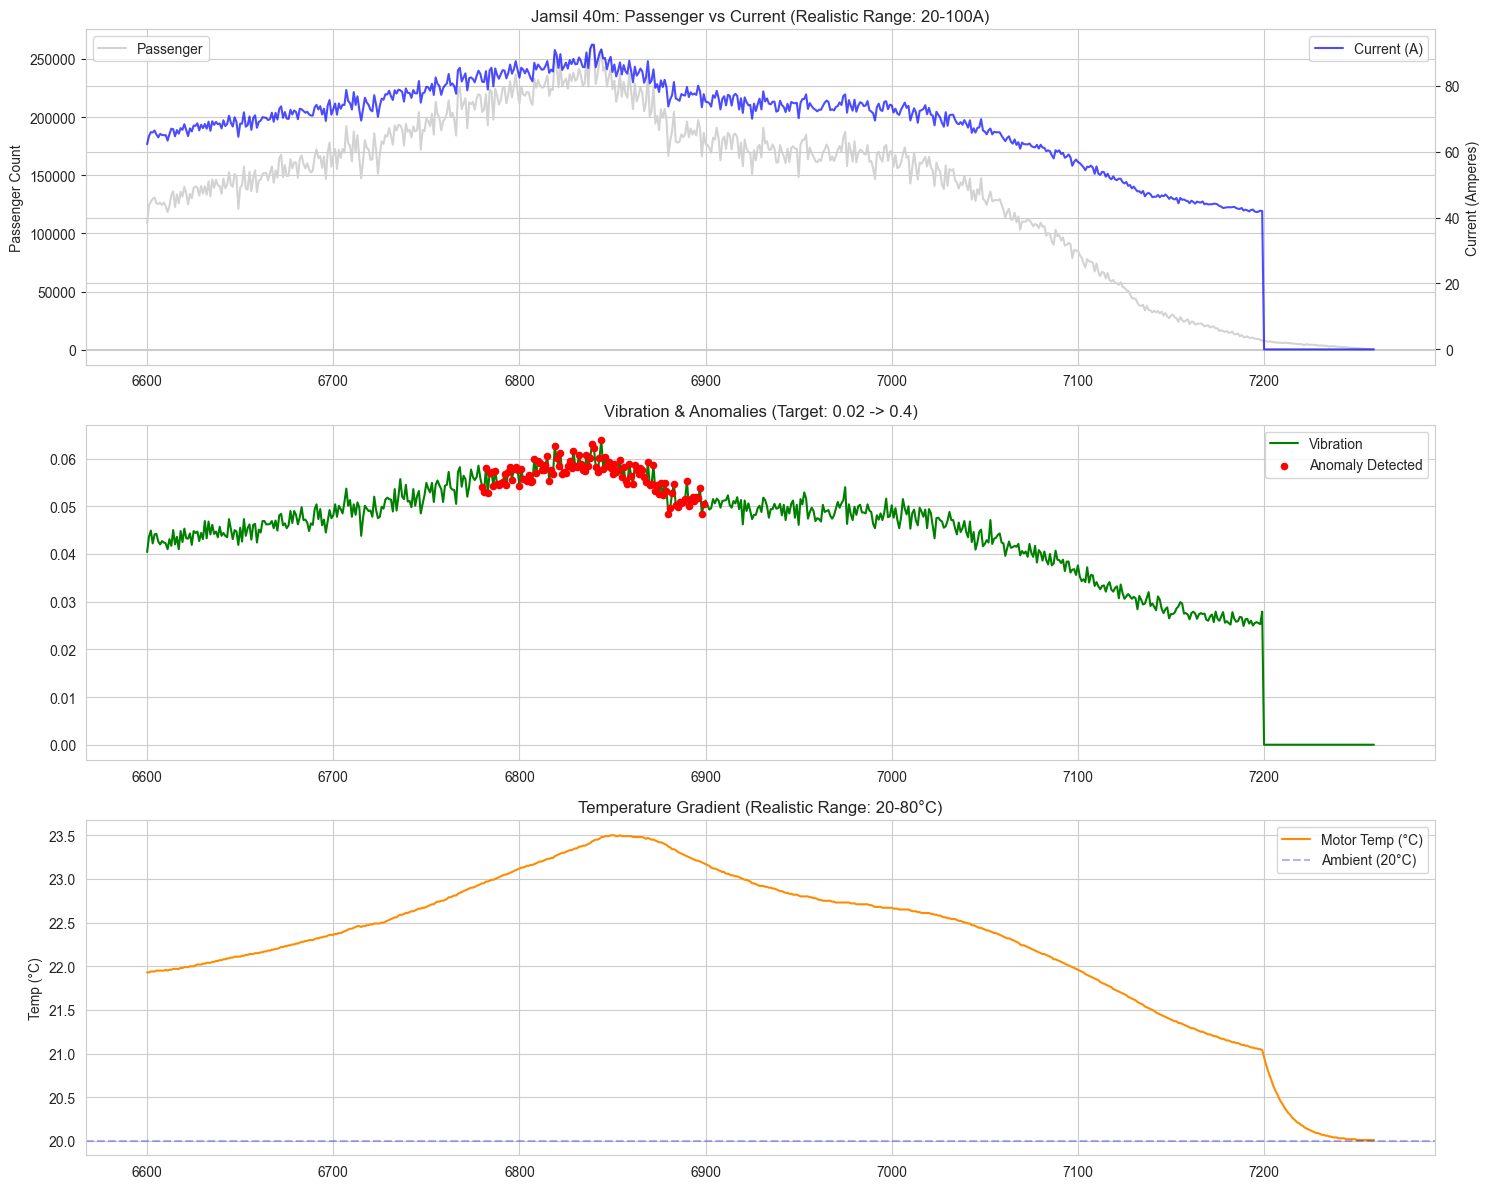

--- [이상치 구간(Label 1) 상세 수치] ---
          Current        Temp         Vib
count  120.000000  120.000000  120.000000
mean    83.701750   23.293333    0.056297
std      4.074486    0.163148    0.003214
min     73.470000   22.950000    0.048300
25%     81.097500   23.180000    0.054500
50%     84.560000   23.310000    0.056900
75%     86.402500   23.450000    0.058400
max     92.450000   23.500000    0.063900


In [16]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# 1. 데이터 불러오기
df_jamsil = pd.read_csv('./final_data/잠실_40m_Minute_final.csv')

# 2. 이상치가 있는 '5일 차' (Hour 113 근처) 추출
# Hour 110부터 120까지 약 10시간 정도를 자세히 봅니다.
sample_df = df_jamsil[(df_jamsil['Hour'] >= 110) & (df_jamsil['Hour'] <= 120)]

plt.figure(figsize=(15, 12))
sns.set_style("whitegrid")

# (1) 승객 수 & 전류
plt.subplot(3, 1, 1)
ax1 = plt.gca()
ax2 = ax1.twinx()
ax1.plot(sample_df.index, sample_df['PassengerCount'], color='lightgray', label='Passenger')
ax2.plot(sample_df.index, sample_df['Current'], color='blue', alpha=0.7, label='Current (A)')
ax1.set_ylabel('Passenger Count')
ax2.set_ylabel('Current (Amperes)')
plt.title('Jamsil 40m: Passenger vs Current (Realistic Range: 20-100A)')
ax1.legend(loc='upper left'); ax2.legend(loc='upper right')

# (2) 진동 & 이상치 표시 (빨간 점)
plt.subplot(3, 1, 2)
plt.plot(sample_df.index, sample_df['Vib'], color='green', label='Vibration')
# 이상치(Label 1) 표시
anomalies = sample_df[sample_df['Label'] == 1]
plt.scatter(anomalies.index, anomalies['Vib'], color='red', s=20, label='Anomaly Detected', zorder=3)
plt.title('Vibration & Anomalies (Target: 0.02 -> 0.4)')
plt.legend()

# (3) 온도 변화 (열평형 확인)
plt.subplot(3, 1, 3)
plt.plot(sample_df.index, sample_df['Temp'], color='darkorange', label='Motor Temp (°C)')
plt.axhline(y=20, color='blue', linestyle='--', alpha=0.3, label='Ambient (20°C)')
plt.title('Temperature Gradient (Realistic Range: 20-80°C)')
plt.ylabel('Temp (°C)')
plt.legend()

plt.tight_layout()
plt.show()

# 이상치 구간의 평균 수치 출력
print("--- [이상치 구간(Label 1) 상세 수치] ---")
print(anomalies[['Current', 'Temp', 'Vib']].describe())